In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline


In [2]:
df = pd.read_csv("dataset_limpio.csv")

# Separar features y target
X = df.drop(columns=["particle_type"])
y = df["particle_type"]

# Codificar labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
classes = le.classes_

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)


In [3]:
%%time
mlp_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(100,50),
        activation="relu",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=500,
        random_state=42
    ))
])

mlp_pipe.fit(X_train, y_train)


CPU times: user 2min 16s, sys: 8min 7s, total: 10min 23s
Wall time: 1min 59s


Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 MLPClassifier(alpha=0.001, hidden_layer_sizes=(100, 50),
                               max_iter=500, random_state=42))])

In [4]:
y_pred = mlp_pipe.predict(X_test)

print("=== Reporte de clasificación — MLP ===")
print(classification_report(y_test, y_pred, target_names=classes))


=== Reporte de clasificación — MLP ===
              precision    recall  f1-score   support

    electron       0.33      0.10      0.16        29
        muon       0.00      0.00      0.00        80
      photon       1.00      1.00      1.00        50
       track       0.98      1.00      0.99      6022

    accuracy                           0.98      6181
   macro avg       0.58      0.53      0.54      6181
weighted avg       0.97      0.98      0.97      6181



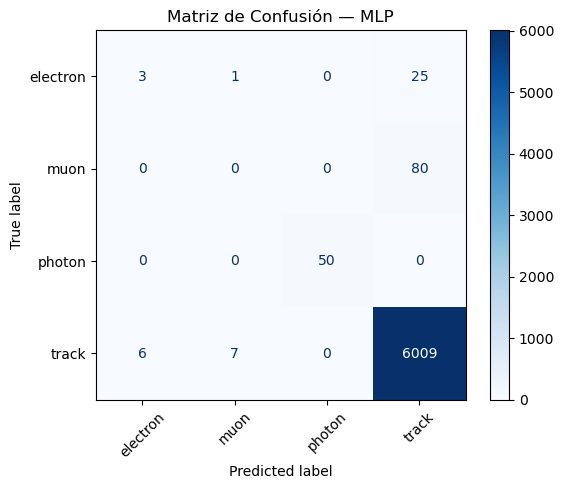

In [5]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de Confusión — MLP")
plt.show()


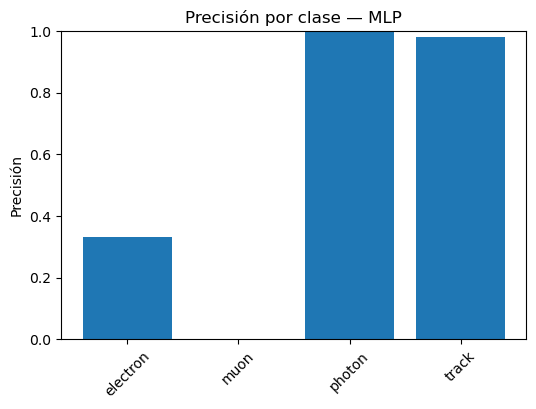

In [6]:
cr = classification_report(y_test, y_pred, target_names=classes, output_dict=True)

precisiones = [cr[c]["precision"] for c in classes]

plt.figure(figsize=(6,4))
plt.bar(classes, precisiones)
plt.ylabel("Precisión")
plt.title("Precisión por clase — MLP")
plt.ylim(0,1)
plt.xticks(rotation=45)
plt.show()


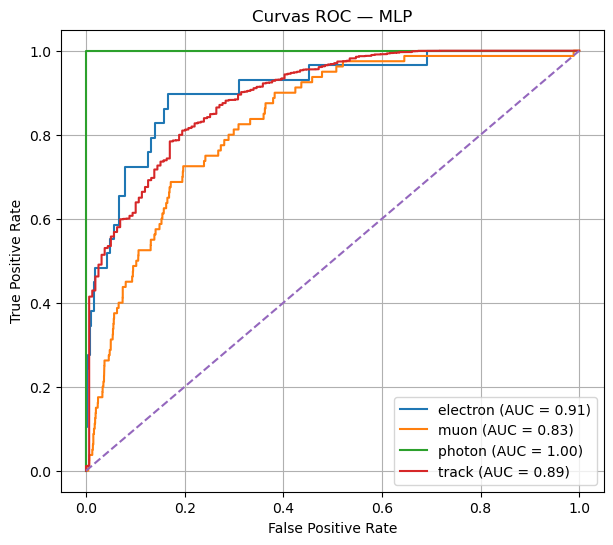

In [7]:
# One-hot para ROC
y_test_bin = label_binarize(y_test, classes=np.arange(len(classes)))
y_proba = mlp_pipe.predict_proba(X_test)

plt.figure(figsize=(7,6))

for i, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC — MLP")
plt.legend()
plt.grid()
plt.show()


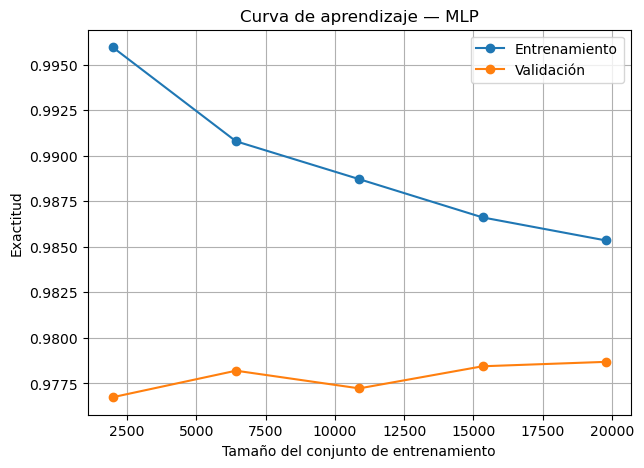

In [8]:
train_sizes, train_scores, test_scores = learning_curve(
    mlp_pipe,
    X_train,
    y_train,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_mean, marker='o', label='Entrenamiento')
plt.plot(train_sizes, test_mean, marker='o', label='Validación')
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("Exactitud")
plt.title("Curva de aprendizaje — MLP")
plt.legend()
plt.grid()
plt.show()


## SIN TRACKS

In [9]:
df = pd.read_csv("dataset_limpio_notracks.csv")

# Separar features y target
X = df.drop(columns=["particle_type"])
y = df["particle_type"]

# Codificar labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
classes = le.classes_

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)


In [10]:
%%time
mlp_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(100,50),
        activation="relu",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=500,
        random_state=42
    ))
])

mlp_pipe.fit(X_train, y_train)


CPU times: user 10.1 s, sys: 33.8 s, total: 43.9 s
Wall time: 7.04 s


/usr/lib/python3/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 MLPClassifier(alpha=0.001, hidden_layer_sizes=(100, 50),
                               max_iter=500, random_state=42))])

In [11]:
y_pred = mlp_pipe.predict(X_test)

print("=== Reporte de clasificación — MLP ===")
print(classification_report(y_test, y_pred, target_names=classes))


=== Reporte de clasificación — MLP ===
              precision    recall  f1-score   support

    electron       0.67      0.41      0.51        29
        muon       0.81      0.93      0.87        80
      photon       1.00      1.00      1.00        50

    accuracy                           0.86       159
   macro avg       0.83      0.78      0.79       159
weighted avg       0.85      0.86      0.84       159



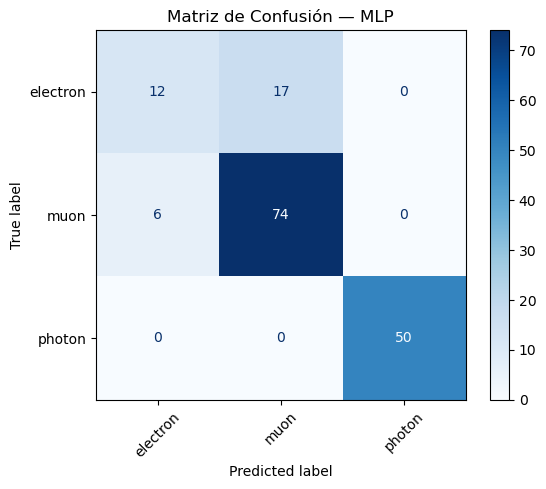

In [12]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de Confusión — MLP")
plt.show()


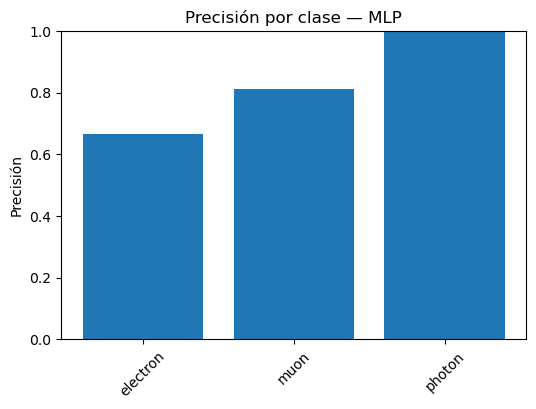

In [13]:
cr = classification_report(y_test, y_pred, target_names=classes, output_dict=True)

precisiones = [cr[c]["precision"] for c in classes]

plt.figure(figsize=(6,4))
plt.bar(classes, precisiones)
plt.ylabel("Precisión")
plt.title("Precisión por clase — MLP")
plt.ylim(0,1)
plt.xticks(rotation=45)
plt.show()


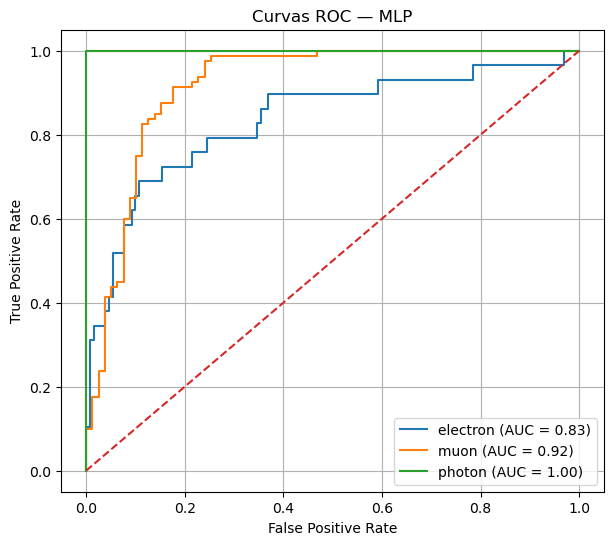

In [14]:
# One-hot para ROC
y_test_bin = label_binarize(y_test, classes=np.arange(len(classes)))
y_proba = mlp_pipe.predict_proba(X_test)

plt.figure(figsize=(7,6))

for i, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC — MLP")
plt.legend()
plt.grid()
plt.show()


/usr/lib/python3/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Opti

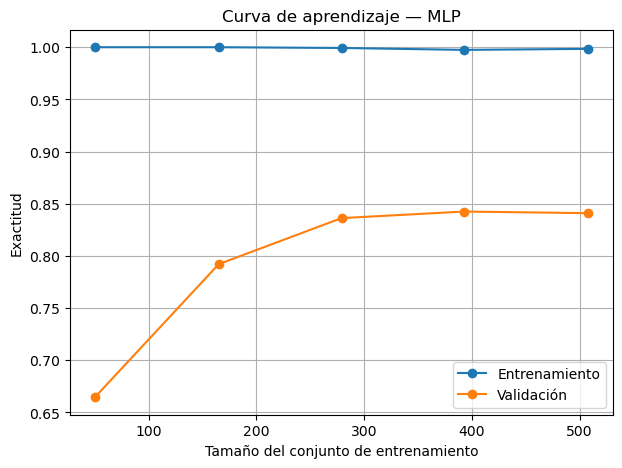

In [15]:
train_sizes, train_scores, test_scores = learning_curve(
    mlp_pipe,
    X_train,
    y_train,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_mean, marker='o', label='Entrenamiento')
plt.plot(train_sizes, test_mean, marker='o', label='Validación')
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("Exactitud")
plt.title("Curva de aprendizaje — MLP")
plt.legend()
plt.grid()
plt.show()
